# Compare nROI and the number of species predicted by BirdNET-Analyzer (v2.4)

## 1. Load packages and custom functions

In [343]:
# -*- coding: utf-8 -*-
"""
Updated 21 July 2021
Author: Sylvain Haupert
"""

from IPython import get_ipython
print(__doc__)

# Clear all the variables
get_ipython().run_line_magic('reset', '-sf')

# suppress all warnings
import warnings
warnings.filterwarnings("ignore")
# from pathlib import Path 
import matplotlib.pyplot as plt
import pandas as pd 
from pathlib import Path 
import os
import sys
import numpy as np
from numpy import mean
from sklearn.metrics import r2_score

import seaborn as sns

# maad
from maad.util import heatmap_by_date_and_time

# Close all the figures (like in Matlab)
plt.close("all")

# # set the current working directory to the location of this script
# abspath = os.path.abspath(get_ipython().run_line_magic('pwd', ''))
# os.chdir(abspath + '/notebooks')

# Import configuration file
sys.path.append(str(Path('../src')))
import config as cfg
import stat_func


Updated 21 July 2021
Author: Sylvain Haupert



## 2. Birdnet-Analyzer (v2.4) dataset

In [344]:
"""==============================================================================
    options             
=============================================================================="""
SAVE = True

# Load the configuration file
CONFIG = cfg.load_config('config_publication_risoux.yaml')

INDICE_TO_DISPLAY = 'nROI' 

# parameters for the regression model found using another dataset
COEF = 0.025 
INTERCEPT = 0.996


In [345]:
# read the csv file with panda
df = pd.read_csv('/media/haupert/DATA/Sylvain/mes_projet_data/dB@Risoux/BirdNET_CombinedTable.csv')

# select the rows where the 'File' column contains "/media/dubois/LaCie/db@risoux/2019/MAGNETO_03"
df_filtered = df[df['File'].str.contains("/media/dubois/LaCie/db@risoux/2019/MAGNETO_03")]

# create a new column with the filename only (without the path)
df_filtered['Filename'] = df_filtered['File'].apply(lambda x: x.split('/')[-1])

# Find the species richness for each file
df_birdnet = df_filtered.groupby('Filename')['Scientific name'].nunique().reset_index()

# add a new column to the species_richness dataframe with the date of the recording, extracted from the filename (S4A03536_20190101_090000.wav) in datetime format
df_birdnet['date'] = pd.to_datetime(df_birdnet['Filename'].str[9:23], format='%Y%m%d_%H%M%S')

# set Date as DateTimeIndex
df_birdnet.set_index('date', inplace=True)

# replace the name of the column 'Scientific name' to 'Avian Species Richness Predicted over 1-minute Soundscape'
df_birdnet.rename(columns={'Scientific name': 'Avian Species Richness Predicted over 1-minute Soundscape'}, inplace=True)

df_birdnet

,Filename,Avian Species Richness Predicted over 1-minute Soundscape
date,,
2019-01-01 09:00:00,S4A03536_20190101_090000.wav,2
2019-01-01 10:30:00,S4A03536_20190101_103000.wav,3
2019-01-01 10:45:00,S4A03536_20190101_104500.wav,2
2019-01-01 13:15:00,S4A03536_20190101_131500.wav,1
2019-01-01 13:30:00,S4A03536_20190101_133000.wav,2
...,...,...
2019-12-31 19:45:00,S4A03536_20191231_194500.wav,1
2019-12-31 20:30:00,S4A03536_20191231_203000.wav,1
2019-12-31 21:00:00,S4A03536_20191231_210000.wav,1


In [346]:
# create rows with missing dates in the index and fill them with 0 values for the 'Avian Species Richness Predicted over 1-minute Soundscape' column
# create a date range from the minimum to the maximum date in the index with a frequency of 15 minute
date_range = pd.date_range(start=df_birdnet.index.min(), end=df_birdnet.index.max(), freq='15min')
df_birdnet = df_birdnet.reindex(date_range, fill_value=0)

# rename the index to 'date'
df_birdnet.index.name = 'date'

df_birdnet

,Filename,Avian Species Richness Predicted over 1-minute Soundscape
date,,
2019-01-01 09:00:00,S4A03536_20190101_090000.wav,2
2019-01-01 09:15:00,0,0
2019-01-01 09:30:00,0,0
2019-01-01 09:45:00,0,0
2019-01-01 10:00:00,0,0
...,...,...
2019-12-31 20:45:00,0,0
2019-12-31 21:00:00,S4A03536_20191231_210000.wav,1
2019-12-31 21:15:00,0,0


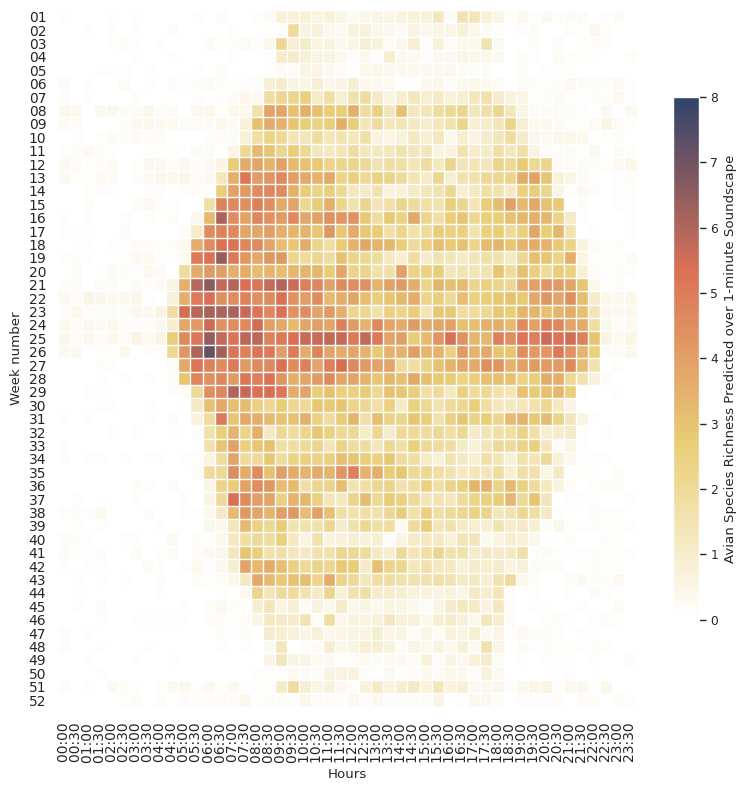

In [ ]:
# maad
from maad.util import heatmap_by_date_and_time

from matplotlib.colors import LinearSegmentedColormap

# Create custom colormap: dark green -> yellow -> light green
colors = ["#FFFFFF", "#E9CE77", "#DB7156", "#31436B"]  # dark green, yellow, light green
custom_cmap = LinearSegmentedColormap.from_list('custom_green_yellow', colors)

# change the color map from blue to dark green passing through yellow and light green
_,_, fig, ax = heatmap_by_date_and_time(df_birdnet, 
                disp_column = 'Avian Species Richness Predicted over 1-minute Soundscape', 
                date_format = "%V",
                time_resolution='30min',
                start_hour='00:00',
                date_min_to_disp = 1,
                date_max_to_disp = 12,
                figsize=(8,8),
                vmin = np.percentile(df_birdnet['Avian Species Richness Predicted over 1-minute Soundscape'], 1),
                vmax = np.percentile(df_birdnet['Avian Species Richness Predicted over 1-minute Soundscape'], 99),
                # vmin = 1,
                # vmax = 8,
                cmap=custom_cmap,
                )

# # save figure
# if SAVE:
#     fig.savefig(os.path.join(CONFIG['save_dir'], 'figure_7_birdnet.png'), dpi=300)

In [348]:
df_nroi = pd.read_csv(os.path.join(
                            CONFIG['save_dir'], 
                            'indices_full_year_risoux_BWNoneHz_NoneHz_16db.csv'),
                            sep=',')

df_nroi['date'] = pd.to_datetime(df_nroi['Date'])
df_nroi = df_nroi.drop(columns=['Date'])
df_nroi = df_nroi.set_index('date')

# add a column nspecies
df_nroi['Avian Species Richness Predicted over 1-minute Soundscape'] = df_nroi[INDICE_TO_DISPLAY]*COEF + INTERCEPT

Overlapping bins: 34977
Pearson r = 0.772
p-value = 0
R^2 = 0.511


,nROI,BirdNET
date,,
2019-01-01 09:00:00,2.146438,2
2019-01-01 09:15:00,0.996000,0
2019-01-01 09:30:00,1.171067,0
2019-01-01 09:45:00,1.171067,0
2019-01-01 10:00:00,1.046019,0


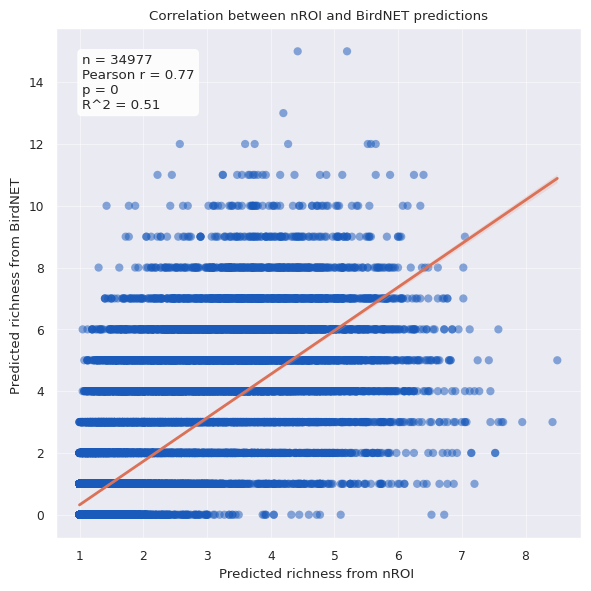

In [ ]:
from scipy.stats import gaussian_kde

# correlation between the species richness predictions from df_nroi and df_birdnet 
target_col = 'Avian Species Richness Predicted over 1-minute Soundscape'

df_corr = (
    df_nroi[[target_col]]
    .rename(columns={target_col: 'nROI'})
    .join(
        df_birdnet[[target_col]].rename(columns={target_col: 'BirdNET'}),
        how='inner'
    )
    .dropna()
    .sort_index()
)

if df_corr.empty:
    raise ValueError('No overlapping timestamps between df_nroi and df_birdnet.')

pearson_r, pearson_p = stat_func.linear_corr(
    df_corr['nROI'],
    df_corr['BirdNET'],
    corr_method='pearson'
)
r2 = r2_score(df_corr['BirdNET'], df_corr['nROI'])

print(f'Overlapping bins: {len(df_corr)}')
print(f'Pearson r = {pearson_r:.3f}')
print(f'p-value = {pearson_p:.4g}')
print(f'R^2 = {r2:.3f}')


fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    df_corr['nROI'],
    df_corr['BirdNET'],
    c = "#195ABB", 
    s=35,
    alpha=0.5,
    edgecolor='none'
)
sns.regplot(
    data=df_corr,
    x='nROI',
    y='BirdNET',
    scatter=False,
    line_kws={'color': '#DB7156', 'lw': 2},
    ax=ax
)

ax.set_xlabel('Predicted richness from nROI ')
ax.set_ylabel('Predicted richness from BirdNET ')
ax.set_title('Correlation between nROI and BirdNET predictions')
ax.text(
    0.05,
    0.95,
    (
        f'n = {len(df_corr)}\n'
        f'Pearson r = {pearson_r:.2f}\n'
        f'p = {pearson_p:.3g}\n'
        f'R^2 = {r2:.2f}'
    ),
    transform=ax.transAxes,
    va='top',
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9}
)
ax.grid(alpha=0.5)
fig.tight_layout()

# if SAVE:
#     fig.savefig(
#         os.path.join(CONFIG['save_dir'], 'figure_9_birdnet_vs_nroi_correlation_week_30min.png'),
#         dpi=300
#     )

df_corr.head()

In [ ]:
# aggregate the data by week and half-hour, and compute the mean of the predicted richness from nROI and BirdNET
df_nroi_agg,_,_,_ = heatmap_by_date_and_time(df_nroi, 
                disp_column = 'Avian Species Richness Predicted over 1-minute Soundscape', 
                date_format = "%V",
                time_resolution='30min',
                start_hour='00:00',
                date_min_to_disp = 1,
                date_max_to_disp = 12,
                )
df_birdnet_agg,_,_,_ = heatmap_by_date_and_time(df_birdnet, 
                disp_column = 'Avian Species Richness Predicted over 1-minute Soundscape', 
                date_format = "%V",
                time_resolution='30min',
                start_hour='00:00',
                date_min_to_disp = 1,
                date_max_to_disp = 12,
                )

# transform the aggregated dataframes into long format for plotting
df_nroi_agg_long = df_nroi_agg.reset_index().melt(id_vars='time', var_name='week', value_name='nROI')
df_birdnet_agg_long = df_birdnet_agg.reset_index().melt(id_vars='time', var_name='week', value_name='BirdNET')

Overlapping bins: 2496
Pearson r = 0.930
p-value = 0
R^2 = 0.687


,time,week,nROI,BirdNET
0,00:00,01,1.066339,0.071429
1,00:30,01,1.044456,0.000000
2,01:00,01,1.063213,0.000000
3,01:30,01,1.028825,0.000000
4,02:00,01,1.036640,0.071429


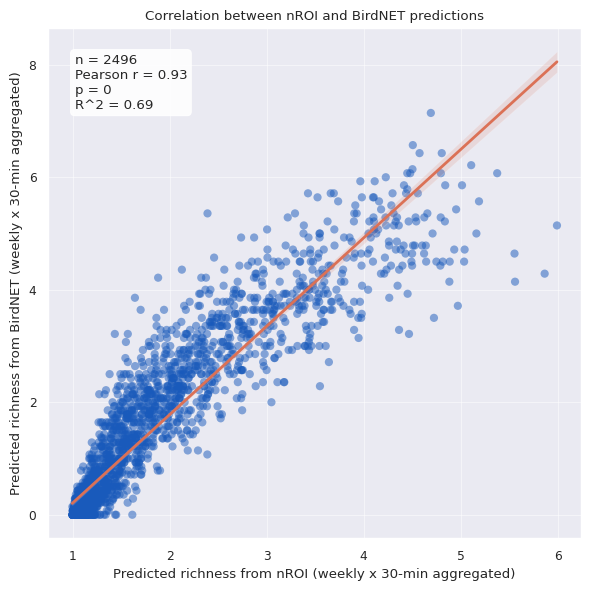

In [ ]:
# correlation between the species richness predictions from df_nroi_agg and df_birdnet_agg
from scipy.stats import gaussian_kde

df_corr = (
    df_nroi_agg_long
    .merge(df_birdnet_agg_long, on=['time', 'week'], how='inner')
    .dropna(subset=['nROI', 'BirdNET'])
    .sort_values(['week', 'time'])
)
if df_corr.empty:
    raise ValueError('No overlapping week/time bins between aggregated nROI and BirdNET.')

pearson_r, pearson_p = stat_func.linear_corr(
    df_corr['nROI'],
    df_corr['BirdNET'],
    corr_method='pearson'
)
r2 = r2_score(df_corr['BirdNET'], df_corr['nROI'])

print(f'Overlapping bins: {len(df_corr)}')
print(f'Pearson r = {pearson_r:.3f}')
print(f'p-value = {pearson_p:.4g}')
print(f'R^2 = {r2:.3f}')

# xy = np.vstack([df_corr['nROI'].to_numpy(), df_corr['BirdNET'].to_numpy()])
# density = gaussian_kde(xy)(xy)
# order = density.argsort()
# x_sorted = df_corr['nROI'].to_numpy()[order]
# y_sorted = df_corr['BirdNET'].to_numpy()[order]
# density_sorted = density[order]

fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    df_corr['nROI'],
    df_corr['BirdNET'],
    c = "#195ABB", 
    s=35,
    alpha=0.5,
    edgecolor='none'
)
sns.regplot(
    data=df_corr,
    x='nROI',
    y='BirdNET',
    scatter=False,
    line_kws={'color': '#DB7156', 'lw': 2},
    ax=ax
)

ax.set_xlabel('Predicted richness from nROI (weekly x 30-min aggregated)')
ax.set_ylabel('Predicted richness from BirdNET (weekly x 30-min aggregated)')
ax.set_title('Correlation between nROI and BirdNET predictions')
ax.text(
    0.05,
    0.95,
    (
        f'n = {len(df_corr)}\n'
        f'Pearson r = {pearson_r:.2f}\n'
        f'p = {pearson_p:.3g}\n'
        f'R^2 = {r2:.2f}'
    ),
    transform=ax.transAxes,
    va='top',
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9}
)
ax.grid(alpha=0.5)
fig.tight_layout()

# if SAVE:
#     fig.savefig(
#         os.path.join(CONFIG['save_dir'], 'figure_9_birdnet_vs_nroi_correlation_week_30min.png'),
#         dpi=300
#     )

df_corr.head()

## 3. Other datasets


In [359]:
# DATASET = "ECUADOR"
# NROI_FILE = "indices_ecuador_BWNoneHz_NoneHz_16db.csv"

# DATASET = "UK_SUSSEX"
# NROI_FILE = "indices_uk_sussex_countryside_BWNoneHz_NoneHz_16db.csv"

# DATASET = "PERU"
# NROI_FILE = "indices_peru_BWNoneHz_NoneHz_16db.csv"

DATASET = "HAWAI"
NROI_FILE = "indices_hawai_BWNoneHz_NoneHz_16db.csv"

# DATASET = "WABAD"
# NROI_FILE = "indices_wabad_BWNoneHz_NoneHz_16db.csv"


In [360]:
df_nroi = pd.read_csv(os.path.join(
                            CONFIG['save_dir'], 
                            NROI_FILE),
                            sep=',')

if DATASET == "PERU":
    df_nroi['date'] = pd.to_datetime(df_nroi['Date'])
    df_nroi = df_nroi.drop(columns=['Date'])
    df_nroi = df_nroi.set_index('date')

    # add minutes to the index based on the last 2 digits of the filename (../data/Peru/audio/PER_006_S08_20190116_100007Z_45.wav) in datetime format
    df_nroi.index = df_nroi.index + pd.to_timedelta(df_nroi['file'].str[-6:-4].astype(int), unit='m')   

    # set to 0 the second in Date
    df_nroi.index = df_nroi.index - pd.to_timedelta(7, unit='s')   

    # subtract 5 hours to the index of df_nroi to match the timezone
    df_nroi.index = df_nroi.index - pd.to_timedelta(5, unit='h')  

    # reset index to a column 'date'
    df_nroi = df_nroi.reset_index().rename(columns={'index': 'date'})

# format the string in the column 'file' to keep only the filename (../data/Peru/audio/PER_006_S08_20190116_100007Z_45.wav -> PER_006_S08_20190116_100007Z_45)
df_nroi['file'] = df_nroi['file'].apply(lambda x: x.split('/')[-1].split('.')[0])

# set the index of df_nroi to the column 'file'
df_nroi.set_index('file', inplace=True)

# add a column nspecies
df_nroi['Avian Species Richness Predicted over 1-minute Soundscape'] = df_nroi[INDICE_TO_DISPLAY]*COEF + INTERCEPT

# keep only the columns 'Avian Species Richness Predicted over 1-minute Soundscape'
df_nroi = df_nroi[['Avian Species Richness Predicted over 1-minute Soundscape']]

df_nroi

,Avian Species Richness Predicted over 1-minute Soundscape
file,
UHH_001_S01_20161121_150000_00,1.471181
UHH_003_S01_20161121_152000_00,2.196457
UHH_005_S01_20161121_154000_00,2.096419
UHH_007_S01_20161122_060000_00,1.021010
UHH_009_S01_20161122_062000_00,4.947505
...,...
UHH_625_S02_20220323_083000_04,1.946362
UHH_626_S02_20220323_094800_00,3.847086
UHH_627_S02_20220323_100400_00,5.597753


In [361]:
df_birdnet = pd.read_parquet(
    os.path.join(
        "/media/haupert/DATA/Sylvain/mes_projets/28_arithmetics/results/bacpipe/06_embeddings_case_study_02_classif_birdnet/",
        DATASET,
        "detections_method1_threshold_0.01.parquet",
    )
)

# keep only the columns 'filename', 'predicted_species', 'confidence', 'recording_date'
df_birdnet = df_birdnet[['filename', 'predicted_species', 'confidence', 'site']]

# Group by date and filename, and concatenate the lists in predicted_species and confidence columns
df_birdnet = df_birdnet.groupby(['filename']).agg({
    'predicted_species': lambda x: [item for sublist in x for item in sublist],
    'confidence': lambda x: [item for sublist in x for item in sublist]
}   )

# separate date and filename into two columns
df_birdnet = df_birdnet.reset_index()

# rename the column 'filename' to 'file' to match df_nroi
df_birdnet.rename(columns={'filename': 'file'}, inplace=True)

# set the index of df_birdnet to the column 'file' 
df_birdnet.set_index('file', inplace=True)

# filter each list in the predicted_species and confidence based on the corresponding confidence list, keeping only species with confidence >= THRESHOLD (0.1)
THRESHOLD = 0.1
df_birdnet['predicted_species_filtered'] = df_birdnet.apply(
    lambda row: [species for species, conf in zip(row['predicted_species'], row['confidence']) if conf >= THRESHOLD], axis=1
)   
df_birdnet['confidence_filtered'] = df_birdnet.apply(
    lambda row: [conf for species, conf in zip(row['predicted_species'], row['confidence']) if conf >= THRESHOLD], axis=1
)   

# remove no detecction in the predicted_species_filtered list
df_birdnet['predicted_species_filtered'] = df_birdnet['predicted_species_filtered'].apply(lambda x: [species for species in x if species != 'no detection'])    

# add a column with the number of unique species in the predicted_species_filtered list
df_birdnet['Avian Species Richness Predicted over 1-minute Soundscape'] = df_birdnet['predicted_species_filtered'].apply(lambda x: len(set(x)))

# keep only the columns Avian Species Richness Predicted over 1-minute Soundscape
df_birdnet = df_birdnet[['Avian Species Richness Predicted over 1-minute Soundscape']]

df_birdnet

,Avian Species Richness Predicted over 1-minute Soundscape
file,
UHH_001_S01_20161121_150000_00,2
UHH_003_S01_20161121_152000_00,6
UHH_005_S01_20161121_154000_00,4
UHH_007_S01_20161122_060000_00,1
UHH_009_S01_20161122_062000_00,3
...,...
UHH_117_S01_20161127_083000_00,2
UHH_119_S01_20161127_090000_00,2
UHH_121_S01_20161127_093000_00,3


Overlapping bins: 67
Pearson r = -0.170
p-value = 0.1686
R^2 = -2.099


,nROI,BirdNET
file,,
UHH_001_S01_20161121_150000_00,1.471181,2
UHH_003_S01_20161121_152000_00,2.196457,6
UHH_005_S01_20161121_154000_00,2.096419,4
UHH_007_S01_20161122_060000_00,1.021010,1
UHH_009_S01_20161122_062000_00,4.947505,3


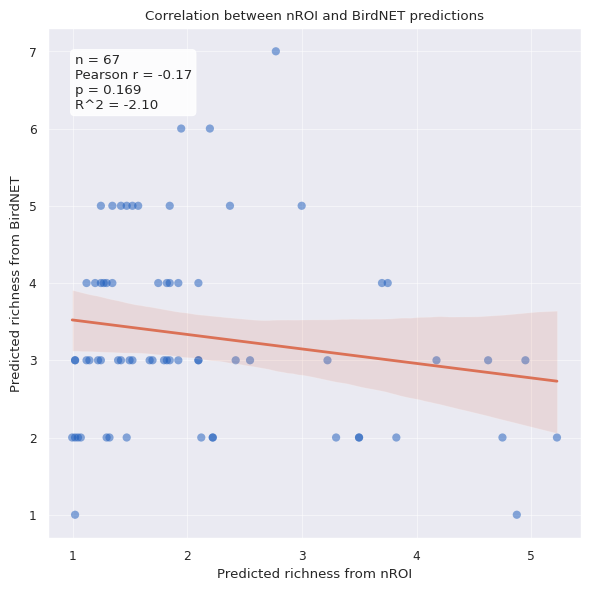

In [ ]:
# correlation between the species richness predictions from df_nroi and df_birdnet 
target_col = 'Avian Species Richness Predicted over 1-minute Soundscape'

df_corr = (
    df_nroi[[target_col]]
    .rename(columns={target_col: 'nROI'})
    .join(
        df_birdnet[[target_col]].rename(columns={target_col: 'BirdNET'}),
        how='inner'
    )
    .dropna()
    .sort_index()
)

if df_corr.empty:
    raise ValueError('No overlapping timestamps between df_nroi and df_birdnet.')

pearson_r, pearson_p = stat_func.linear_corr(
    df_corr['nROI'],
    df_corr['BirdNET'],
    corr_method='pearson'
)
r2 = r2_score(df_corr['BirdNET'], df_corr['nROI'])

print(f'Overlapping bins: {len(df_corr)}')
print(f'Pearson r = {pearson_r:.3f}')
print(f'p-value = {pearson_p:.4g}')
print(f'R^2 = {r2:.3f}')


fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    df_corr['nROI'],
    df_corr['BirdNET'],
    c = "#195ABB", 
    s=35,
    alpha=0.5,
    edgecolor='none'
)
sns.regplot(
    data=df_corr,
    x='nROI',
    y='BirdNET',
    scatter=False,
    line_kws={'color': '#DB7156', 'lw': 2},
    ax=ax
)

ax.set_xlabel('Predicted richness from nROI')
ax.set_ylabel('Predicted richness from BirdNET')
ax.set_title('Correlation between nROI and BirdNET predictions')
ax.text(
    0.05,
    0.95,
    (
        f'n = {len(df_corr)}\n'
        f'Pearson r = {pearson_r:.2f}\n'
        f'p = {pearson_p:.3g}\n'
        f'R^2 = {r2:.2f}'
    ),
    transform=ax.transAxes,
    va='top',
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9}
)
ax.grid(alpha=0.5)
fig.tight_layout()

# if SAVE:
#     fig.savefig(
#         os.path.join(CONFIG['save_dir'], 'figure_10_'+DATASET+'_birdnet_vs_nroi_correlation.png'),
#         dpi=300
#     )

df_corr.head()

In [363]:
df_annot = pd.read_csv(os.path.join('/media/haupert/DATA/Sylvain/mes_projets/28_arithmetics/data/dataset/',
                                    DATASET, 
                                    'species_gt_15min.csv'), sep=',')

# set the index of df_annot to the column 'date' in datetime format
df_annot['date'] = pd.to_datetime(df_annot['date'], format='%Y-%m-%d %H:%M:%S')

# rename filename to file and set as index
df_annot = df_annot.rename(columns={'filename': 'file'}).set_index('file')

# keep only the columns 'date' and 'species_richness'
df_annot = df_annot[['date', 'species_richness']]

df_annot

,date,species_richness
file,,
UHH_001_S01_20161121_150000_00,2016-11-21 15:00:00,1
UHH_003_S01_20161121_152000_00,2016-11-21 15:20:00,2
UHH_005_S01_20161121_154000_00,2016-11-21 15:40:00,2
UHH_007_S01_20161122_060000_00,2016-11-22 06:00:00,0
UHH_009_S01_20161122_062000_00,2016-11-22 06:20:00,3
...,...,...
UHH_625_S02_20220323_083000_04,2022-03-23 08:34:00,3
UHH_626_S02_20220323_094800_00,2022-03-23 09:48:00,4
UHH_627_S02_20220323_100400_00,2022-03-23 10:04:00,5


Overlapping bins: 357
Pearson r = 0.589
p-value = 9.919e-35
R^2 = -0.182


,predicted,observed
file,,
UHH_001_S01_20161121_150000_00,1.471181,1
UHH_003_S01_20161121_152000_00,2.196457,2
UHH_005_S01_20161121_154000_00,2.096419,2
UHH_007_S01_20161122_060000_00,1.021010,0
UHH_009_S01_20161122_062000_00,4.947505,3


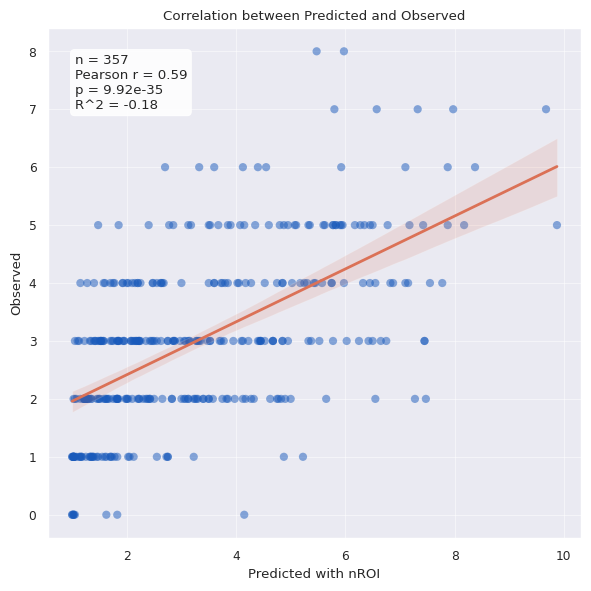

In [ ]:
target_col = 'Avian Species Richness Predicted over 1-minute Soundscape'

df_corr = (
    df_nroi[[target_col]]
    .rename(columns={target_col: 'predicted'})
    .join(
        df_annot[['species_richness']].rename(columns={'species_richness': 'observed'}),
        how='inner'
    )
    .dropna()
    .sort_index()
)

if df_corr.empty:
    raise ValueError('No overlapping timestamps between df_nroi and df_annot.')

pearson_r, pearson_p = stat_func.linear_corr(
    df_corr['predicted'],
    df_corr['observed'],
    corr_method='pearson'
)
r2 = r2_score(df_corr['observed'], df_corr['predicted'])

print(f'Overlapping bins: {len(df_corr)}')
print(f'Pearson r = {pearson_r:.3f}')
print(f'p-value = {pearson_p:.4g}')
print(f'R^2 = {r2:.3f}')


fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    df_corr['predicted'],
    df_corr['observed'],
    c = "#195ABB", 
    s=35,
    alpha=0.5,
    edgecolor='none'
)
sns.regplot(
    data=df_corr,
    x='predicted',
    y='observed',
    scatter=False,
    line_kws={'color': '#DB7156', 'lw': 2},
    ax=ax
)

ax.set_xlabel('Predicted with nROI')
ax.set_ylabel('Observed')
ax.set_title('Correlation between Predicted and Observed')
ax.text(
    0.05,
    0.95,
    (
        f'n = {len(df_corr)}\n'
        f'Pearson r = {pearson_r:.2f}\n'
        f'p = {pearson_p:.3g}\n'
        f'R^2 = {r2:.2f}'
    ),
    transform=ax.transAxes,
    va='top',
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9}
)
ax.grid(alpha=0.5)
fig.tight_layout()

# if SAVE:
#     fig.savefig(
#         os.path.join(CONFIG['save_dir'], 'figure_11_'+DATASET+'_nroi_vs_gt.png'),
#         dpi=300
#     )

df_corr.head()

Overlapping bins: 67
Pearson r = 0.543
p-value = 2.087e-06
R^2 = -1.094


,predicted,observed
file,,
UHH_001_S01_20161121_150000_00,2,1
UHH_003_S01_20161121_152000_00,6,2
UHH_005_S01_20161121_154000_00,4,2
UHH_007_S01_20161122_060000_00,1,0
UHH_009_S01_20161122_062000_00,3,3


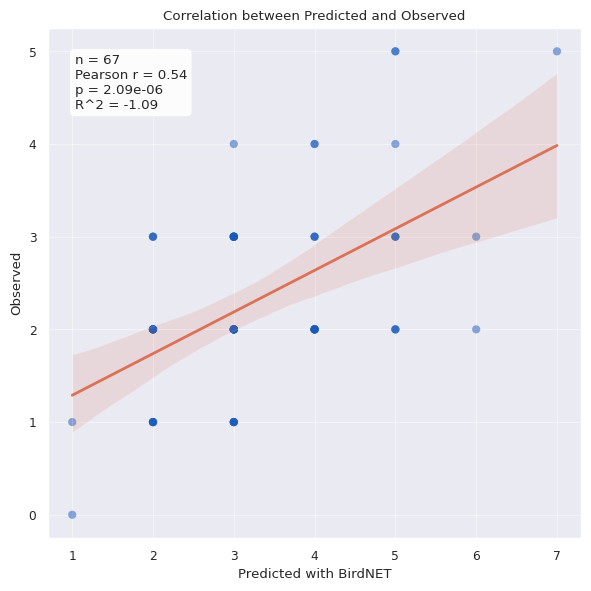

In [ ]:
target_col = 'Avian Species Richness Predicted over 1-minute Soundscape'

df_corr = (
    df_birdnet[[target_col]]
    .rename(columns={target_col: 'predicted'})
    .join(
        df_annot[['species_richness']].rename(columns={'species_richness': 'observed'}),
        how='inner'
    )
    .dropna()
    .sort_index()
)

if df_corr.empty:
    raise ValueError('No overlapping timestamps between df_nroi and df_birdnet.')

pearson_r, pearson_p = stat_func.linear_corr(
    df_corr['predicted'],
    df_corr['observed'],
    corr_method='pearson'
)
r2 = r2_score(df_corr['observed'], df_corr['predicted'])

print(f'Overlapping bins: {len(df_corr)}')
print(f'Pearson r = {pearson_r:.3f}')
print(f'p-value = {pearson_p:.4g}')
print(f'R^2 = {r2:.3f}')


fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(
    df_corr['predicted'],
    df_corr['observed'],
    c = "#195ABB", 
    s=35,
    alpha=0.5,
    edgecolor='none'
)
sns.regplot(
    data=df_corr,
    x='predicted',
    y='observed',
    scatter=False,
    line_kws={'color': '#DB7156', 'lw': 2},
    ax=ax
)

ax.set_xlabel('Predicted with BirdNET')
ax.set_ylabel('Observed')
ax.set_title('Correlation between Predicted and Observed')
ax.text(
    0.05,
    0.95,
    (
        f'n = {len(df_corr)}\n'
        f'Pearson r = {pearson_r:.2f}\n'
        f'p = {pearson_p:.3g}\n'
        f'R^2 = {r2:.2f}'
    ),
    transform=ax.transAxes,
    va='top',
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9}
)
ax.grid(alpha=0.5)
fig.tight_layout()

# if SAVE:
#     fig.savefig(
#         os.path.join(CONFIG['save_dir'], 'figure_11_'+DATASET+'_birdnet_vs_gt.png'),
#         dpi=300
#     )

df_corr.head()